In [1]:
import pandas as pd
import numpy as np
import random
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    KFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    matthews_corrcoef
)

from sklearn.feature_selection import RFECV

import optuna
import pickle

In [ ]:
X_train = pd.read_csv(r'C:\Users\User\PROJECTS\Comparison\1000&161\bert\X_train.csv')
X_train.drop('sequence', axis = 1, inplace = True)
X_test = pd.read_csv(r'C:\Users\User\PROJECTS\Comparison\1000&161\bert\X_test.csv')
X_test.drop('sequence', axis = 1, inplace = True)

y_train = pd.read_csv(r'C:\Users\User\PROJECTS\Comparison\1000&161\bert\y_train.csv', index_col = 0)
y_test = pd.read_csv(r'C:\Users\User\PROJECTS\Comparison\1000&161\bert\y_test.csv', index_col = 0)

LGBM

In [6]:
LGBM_model = LGBMClassifier(random_state = 42, verbose = -1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state = 42)

rfecv = RFECV(estimator=LGBM_model, step=10, cv=cv, scoring='matthews_corrcoef', verbose=1)
rfecv.fit(X_train, y_train)

print("Оптимальное количество признаков:", rfecv.n_features_)
print("Выбранные признаки:", X_train.columns[rfecv.support_].tolist())
LGBM_sel_features = X_train.columns[rfecv.support_].tolist()

Fitting estimator with 768 features.
Fitting estimator with 758 features.
Fitting estimator with 748 features.
Fitting estimator with 738 features.
Fitting estimator with 728 features.
Fitting estimator with 718 features.
Fitting estimator with 708 features.
Fitting estimator with 698 features.
Fitting estimator with 688 features.
Fitting estimator with 678 features.
Fitting estimator with 668 features.
Fitting estimator with 658 features.
Fitting estimator with 648 features.
Fitting estimator with 638 features.
Fitting estimator with 628 features.
Fitting estimator with 618 features.
Fitting estimator with 608 features.
Fitting estimator with 598 features.
Fitting estimator with 588 features.
Fitting estimator with 578 features.
Fitting estimator with 568 features.
Fitting estimator with 558 features.
Fitting estimator with 548 features.
Fitting estimator with 538 features.
Fitting estimator with 528 features.
Fitting estimator with 518 features.
Fitting estimator with 508 features.
F

In [9]:
LGBM_sel_features

['emb_5',
 'emb_8',
 'emb_27',
 'emb_32',
 'emb_39',
 'emb_60',
 'emb_68',
 'emb_95',
 'emb_102',
 'emb_111',
 'emb_114',
 'emb_115',
 'emb_126',
 'emb_149',
 'emb_155',
 'emb_158',
 'emb_172',
 'emb_177',
 'emb_181',
 'emb_200',
 'emb_215',
 'emb_228',
 'emb_243',
 'emb_249',
 'emb_251',
 'emb_253',
 'emb_262',
 'emb_305',
 'emb_309',
 'emb_336',
 'emb_353',
 'emb_393',
 'emb_397',
 'emb_452',
 'emb_460',
 'emb_461',
 'emb_484',
 'emb_490',
 'emb_498',
 'emb_601',
 'emb_605',
 'emb_607',
 'emb_644',
 'emb_699',
 'emb_727',
 'emb_758',
 'emb_759',
 'emb_763']

In [7]:
sel_features = LGBM_sel_features
len(sel_features)

48

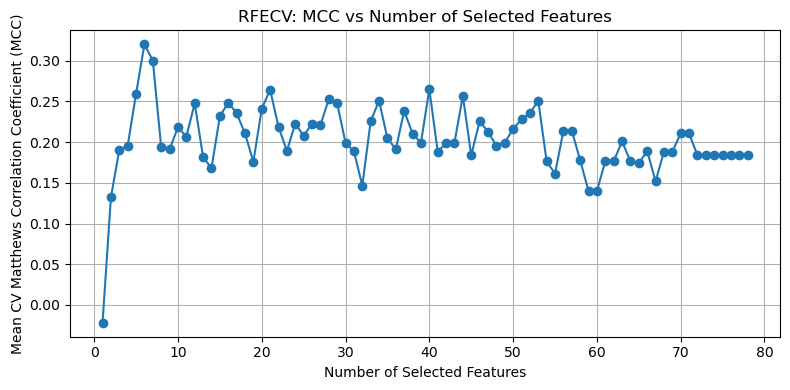

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
    rfecv.cv_results_["mean_test_score"],
    marker='o'
)
plt.title("RFECV: MCC vs Number of Selected Features")
plt.xlabel("Number of Selected Features")
plt.ylabel("Mean CV Matthews Correlation Coefficient (MCC)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
def objective(trial):
    # Подбор гиперпараметров
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.5, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 30),
        'num_leaves': trial.suggest_int('num_leaves', 5, 50),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        'random_state': 42,
        'n_jobs': -1
    }


    model = LGBMClassifier(**param, verbose = -1, is_unbalance=True)


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train[sel_features], y_train, cv=cv, scoring='matthews_corrcoef')


    return scores.mean()

In [ ]:
study_1 = optuna.create_study(direction='maximize')
study_1.optimize(objective, n_trials=100)

print("Лучшие гиперпараметры:")
print(study_1.best_params)

In [10]:
#LGBM_model = LGBMClassifier(**study_1.best_params, random_state = 42, verbose = -1)
LGBM_model = model = LGBMClassifier(
    n_estimators=108,
    learning_rate=0.21957557912548242,
    max_depth=30,
    num_leaves=8,
    min_child_samples=36,
    subsample=0.5297656204323747,
    colsample_bytree=0.9039768149150107,
    reg_alpha=1.605059787694554e-05,
    reg_lambda=0.0002111570122513609,
    class_weight=None,
    boosting_type='gbdt',
    random_state=42,       
    n_jobs=-1,             
    verbosity=-1           
)

LGBM_model.fit(X_train[sel_features], y_train)

# Оценка на тестовой выборке
y_pred = LGBM_model.predict(X_test[sel_features])
print("MCC на тесте:", matthews_corrcoef(y_test, y_pred))

MCC на тесте: 0.3019302841620076


In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(LGBM_model, X_train[sel_features], y_train, cv=skf, scoring='matthews_corrcoef')
for i in range(5):
  print(f'Fold {i+1}: MCC = {scores[i]}')
print('Mean MCC:', scores.mean())

Fold 1: MCC = 0.4975918510563778
Fold 2: MCC = 0.246158090737853
Fold 3: MCC = 0.3151633011947097
Fold 4: MCC = 0.284655693882259
Fold 5: MCC = 0.49023923205727077
Mean MCC: 0.3667616337856941


In [12]:
import joblib

joblib.dump(LGBM_model, 'LGBM_model.pkl')

['LGBM_model.pkl']

RandonForest

In [19]:
RF_model = RandomForestClassifier(random_state = 42)

cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)

rfecv = RFECV(estimator=RF_model, step=10, cv=cv, scoring='matthews_corrcoef', verbose=1)
rfecv.fit(X_train, y_train)

print("Оптимальное количество признаков:", rfecv.n_features_)
print("Выбранные признаки:", X_train.columns[rfecv.support_].tolist())
RF_sel_features = X_train.columns[rfecv.support_].tolist()

Fitting estimator with 768 features.
Fitting estimator with 758 features.
Fitting estimator with 748 features.
Fitting estimator with 738 features.
Fitting estimator with 728 features.
Fitting estimator with 718 features.
Fitting estimator with 708 features.
Fitting estimator with 698 features.
Fitting estimator with 688 features.
Fitting estimator with 678 features.
Fitting estimator with 668 features.
Fitting estimator with 658 features.
Fitting estimator with 648 features.
Fitting estimator with 638 features.
Fitting estimator with 628 features.
Fitting estimator with 618 features.
Fitting estimator with 608 features.
Fitting estimator with 598 features.
Fitting estimator with 588 features.
Fitting estimator with 578 features.
Fitting estimator with 568 features.
Fitting estimator with 558 features.
Fitting estimator with 548 features.
Fitting estimator with 538 features.
Fitting estimator with 528 features.
Fitting estimator with 518 features.
Fitting estimator with 508 features.
F

In [20]:
sel_features = RF_sel_features
len(sel_features)

8

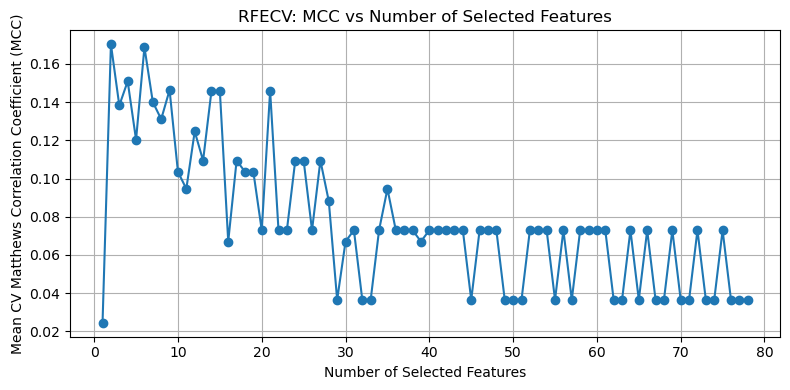

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
    rfecv.cv_results_["mean_test_score"],
    marker='o'
)
plt.title("RFECV: MCC vs Number of Selected Features")
plt.xlabel("Number of Selected Features")
plt.ylabel("Mean CV Matthews Correlation Coefficient (MCC)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 2, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample']),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**param)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train[sel_features], y_train, cv=cv, scoring='matthews_corrcoef')

    return scores.mean()

In [ ]:
study_2 = optuna.create_study(direction='maximize')
study_2.optimize(objective, n_trials=100)

print("Лучшие гиперпараметры:")
print(study_2.best_params)

In [24]:
RF_model = RandomForestClassifier(**study_2.best_params, random_state = 42)

RF_model.fit(X_train[sel_features], y_train)

# Оценка на тестовой выборке
y_pred = RF_model.predict(X_test[sel_features])
print("MCC на тесте:", matthews_corrcoef(y_test, y_pred))

MCC на тесте: 0.22275407605699066


In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(RF_model, X_train[sel_features], y_train, cv=skf, scoring='matthews_corrcoef')
for i in range(5):
  print(f'Fold {i+1}: MCC = {scores[i]}')
print('Mean MCC:', scores.mean())

Fold 1: MCC = 0.4247588491368719
Fold 2: MCC = 0.3563659730377414
Fold 3: MCC = 0.3073326334419233
Fold 4: MCC = 0.3651626707467974
Fold 5: MCC = 0.30208768135776476
Mean MCC: 0.3511415615442197


In [26]:
models = [LGBM_model, RF_model]
models_names = ['LGBM', 'Random_Forest']
selected_features_list = [LGBM_sel_features, RF_sel_features]

def get_metrics(models_list, models_names, selected_features_list):
  roc_auc_metrics = []
  f1_score_metrics = []
  f1_macro_metrics = []
  f1_micro_metrics = []
  precision_metrics = []
  recall_metrics = []
  mcc_metrics = []
  FP = []
  FN = []
  TP = []
  TN = []

  for model, features in zip(models_list, selected_features_list):
    
    y_proba = model.predict_proba(X_test[features])[:, 1]
    y_pred = model.predict(X_test[features])

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    roc_auc_metrics.append(roc_auc_score(y_test, y_proba))
    f1_score_metrics.append(f1_score(y_test, y_pred))
    f1_macro_metrics.append(f1_score(y_test, y_pred, average='macro'))  
    f1_micro_metrics.append(f1_score(y_test, y_pred, average='micro'))
    precision_metrics.append(precision_score(y_test, y_pred))
    recall_metrics.append(recall_score(y_test, y_pred))
    mcc_metrics.append(matthews_corrcoef(y_test, y_pred))
    FP.append(fp)
    FN.append(fn)
    TN.append(tn)
    TP.append(tp)

  data = pd.DataFrame({
    'model': models_names,
    'roc/auc': roc_auc_metrics,
    'f1': f1_score_metrics,
    'f1 (macro)': f1_macro_metrics,
    'f1 (micro)': f1_micro_metrics,
    'precision': precision_metrics,
    'recall': recall_metrics,
    'mcc': mcc_metrics,
    'TN': TN,
    'FP': FP,
    'FN': FN,
    'TP': TP
    })

  return data

In [27]:
results = get_metrics(models, models_names, selected_features_list)
results

,model,roc/auc,f1,f1 (macro),f1 (micro),precision,recall,mcc,TN,FP,FN,TP
0,LGBM,0.755752,0.318182,0.623546,0.871245,0.583333,0.21875,0.301930,196,5,25,7
1,Random_Forest,0.672419,0.301887,0.606149,0.841202,0.380952,0.25000,0.222754,188,13,24,8


Проверка на исходных данных 

In [29]:
df = pd.read_csv(r'C:\Users\User\PROJECTS\Comparison\BERT_testing.csv')

In [30]:
X_test = df.drop(['target', 'sequence'], axis = 1)
y_test = df['target']

In [31]:
models = [LGBM_model, RF_model]
models_names = ['LGBM', 'Random_Forest']
selected_features_list = [LGBM_sel_features, RF_sel_features]

def get_metrics(models_list, models_names, selected_features_list):
  roc_auc_metrics = []
  f1_score_metrics = []
  precision_metrics = []
  recall_metrics = []
  mcc_metrics = []
  FP = []
  FN = []
  TP = []
  TN = []

  for model, features in zip(models_list, selected_features_list):
    
    model.fit(X_train[features], y_train)
    y_proba = model.predict_proba(X_test[features])[:, 1]
    #y_pred = (y_proba >= 0.6).astype(int)
    y_pred = model.predict(X_test[features])

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    roc_auc_metrics.append(roc_auc_score(y_test, y_proba))
    f1_score_metrics.append(f1_score(y_test, y_pred))
    precision_metrics.append(precision_score(y_test, y_pred))
    recall_metrics.append(recall_score(y_test, y_pred))
    mcc_metrics.append(matthews_corrcoef(y_test, y_pred))
    FP.append(fp)
    FN.append(fn)
    TN.append(tn)
    TP.append(tp)

  data = pd.DataFrame({
    'model': models_names,
    'roc/auc': roc_auc_metrics,
    'f1': f1_score_metrics,
    'precision': precision_metrics,
    'recall': recall_metrics,
    'mcc': mcc_metrics,
    'TN': TN,
    'FP': FP,
    'FN': FN,
    'TP': TP
    })

  return data

In [32]:
results = get_metrics(models, models_names, selected_features_list)
results

,model,roc/auc,f1,precision,recall,mcc,TN,FP,FN,TP
0,LGBM,0.934948,0.880259,0.918919,0.844720,0.787686,176,12,25,136
1,Random_Forest,0.898606,0.803987,0.864286,0.751553,0.661599,169,19,40,121
